In [15]:
import pandas as pd

# Extraer la importancia de cada variable
importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("¿En qué se fija más la IA para saber si un cliente se va?")
print(importancias)


¿En qué se fija más la IA para saber si un cliente se va?
   Característica  Importancia
0          tenure     0.536627
1  MonthlyCharges     0.422989
2    TotalCharges     0.040383


In [14]:
# 1. Crear la estructura del Árbol de Decisión
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)

# 2. ENTRENAMIENTO: Aquí la IA estudia los datos pasados
modelo.fit(X_train, y_train)

# 3. PREDICCIÓN: Forzamos a la IA a tomar el examen con los datos de prueba
predicciones = modelo.predict(X_test)

# 4. EVALUACIÓN: Calcular el porcentaje de acierto (Accuracy)
exactitud = accuracy_score(y_test, predicciones)
print(f"¡Entrenamiento completado!")
print(f"La precisión general de la IA es del: {exactitud * 100:.2f}%")


¡Entrenamiento completado!
La precisión general de la IA es del: 77.40%


In [13]:
# 1. Definir las variables predictoras (X) - Las pistas
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# 2. Definir la variable objetivo (y) - Lo que queremos predecir
y = df['Churn_Numerico']

# 3. Dividir los datos: 80% para entrenar la IA y 20% para evaluarla al final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(# Contar cuántos datos quedaron para cada etapa
f"Datos totales: {len(df)}\n"
f"Datos de entrenamiento: {len(X_train)}\n"
f"Datos de prueba: {len(X_test)}"
)


Datos totales: 7032
Datos de entrenamiento: 5625
Datos de prueba: 1407


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

print("¡Librerías de Inteligencia Artificial importadas con éxito!")


¡Librerías de Inteligencia Artificial importadas con éxito!


In [10]:
import numpy as np

# 1. Forzar la conversión a número. Los espacios en blanco se convertirán en 'NaN' (Nulo)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Ahora sí, contar cuántos nulos reales aparecieron
print("Nulos reales después de la conversión:")
print(df['TotalCharges'].isnull().sum())

# 3. Eliminar esas filas vacías para que no estorben (son muy poquitas)
df = df.dropna(subset=['TotalCharges'])

# 4. Verificar que el tipo de dato ahora sea numérico (float64)
print("\nNuevo tipo de dato de TotalCharges:")
print(df['TotalCharges'].dtype)


Nulos reales después de la conversión:
11

Nuevo tipo de dato de TotalCharges:
float64


In [9]:
# Verificar el tipo de datos de las columnas clave
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].dtypes)

# Contar cuántos valores nulos o vacíos detecta Pandas
print("\nValores nulos detectados:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].isnull().sum())


tenure              int64
MonthlyCharges    float64
TotalCharges       object
dtype: object

Valores nulos detectados:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [8]:
# Cambiar 'Yes' por 1 y 'No' por 0 en la columna Churn
df['Churn_Numerico'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verificar el cambio mostrando las columnas originales y la nueva
df[['Churn', 'Churn_Numerico']].head()


,Churn,Churn_Numerico
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


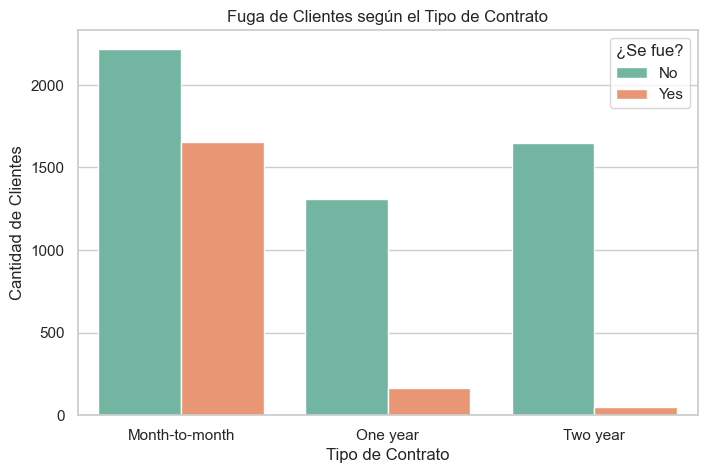

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico que compare el Tipo de Contrato con el Churn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')

# Títulos y etiquetas
plt.title('Fuga de Clientes según el Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='¿Se fue?')

plt.show()



C:\Users\Usuario\AppData\Local\Temp\ipykernel_3588\740531005.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


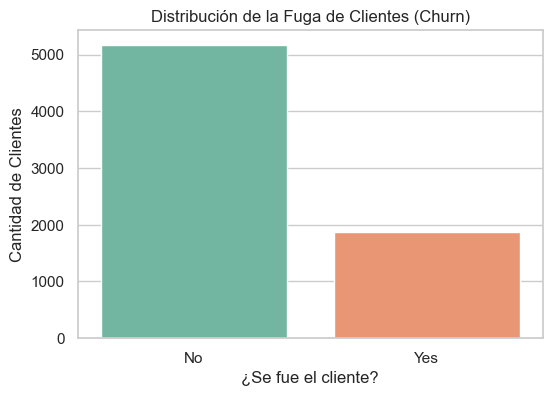

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")

# Crear un gráfico de barras para la columna Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')

# Ponerle títulos bonitos
plt.title('Distribución de la Fuga de Clientes (Churn)')
plt.xlabel('¿Se fue el cliente?')
plt.ylabel('Cantidad de Clientes')

# Mostrar el gráfico en pantalla
plt.show()


In [5]:
# Contar cuántos clientes se van y cuántos se quedan
df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
# Resumen estadístico (promedios, mínimos, máximos) de los números
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
# Ver información de las columnas, tipos de datos y si faltan valores
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [2]:
# Cargar el archivo de datos
df = pd.read_csv('../data/customer_churn.csv')

# Mostrar las primeras 5 filas para revisar el contenido
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1]:
import pandas as pd
print("¡Entorno configurado con éxito!")


¡Entorno configurado con éxito!
